# Ridge HRTF Prediction V2.1

Predicao de HRTF usando features derivadas de meshes 3D

## 1. Setup e Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import trimesh
import scipy.io
import netCDF4
import glob
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

# definir diretorios
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'hutubs'
MESH_DIR = DATA_DIR / 'meshes'
OUTPUT_DIR = BASE_DIR / 'ridge_hrtf_output_v2.1'
MODEL_DIR = OUTPUT_DIR / 'models'
RESULTS_DIR = OUTPUT_DIR / 'results'

# criar diretorios
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# configuracoes HRTF
FS = 44100
TGT_FREQS = np.linspace(1000, 12000, 64)
POS_TGT = [(0,0), (40,0), (320,0), (0,30), (0,-30)]

print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Frequencias alvo: {len(TGT_FREQS)}")

Base directory: /home/augusto/projects/PSO-Spatial-Acoustic-Learning
Data directory: /home/augusto/projects/PSO-Spatial-Acoustic-Learning/data/hutubs
Frequencias alvo: 64


## 2. Extrator de Features V2

In [8]:
class RidgeV2Extractor:
    def __init__(self):
        self.data_path = DATA_DIR
        self.direct_features = ['x1', 'x2', 'x3', 'L_d5', 'L_d6', 'R_d5', 'R_d6']
    
    def load_mesh(self, subject_id):
        mesh_path = self.data_path / f"meshes/pp{subject_id}_3DheadMesh.ply"
        
        if not mesh_path.exists():
            print(f"Arquivo nao encontrado: pp{subject_id}")
            return None
            
        try:
            mesh = trimesh.load(mesh_path, file_type='ply', force='mesh')
            
            if not hasattr(mesh, 'vertices') or len(mesh.vertices) == 0:
                print(f"Mesh pp{subject_id} sem vertices")
                return None
                
            vertices = np.array(mesh.vertices)
            
            if np.max(np.abs(vertices)) < 1:
                vertices = vertices * 1000
                
            return vertices
            
        except Exception as e:
            print(f"Erro ao carregar pp{subject_id}: {e}")
            return None
    
    def extract_ear(self, vertices, side='left'):
        if side == 'left':
            lateral_mask = vertices[:, 1] < np.percentile(vertices[:, 1], 5)
        else:
            lateral_mask = vertices[:, 1] > np.percentile(vertices[:, 1], 95)
        
        lateral_points = vertices[lateral_mask]
        
        if len(lateral_points) < 100:
            return {'d5': 6.0, 'd6': 3.0, 'points': np.array([]), 'valid': False}
            
        z_min, z_max = vertices[:, 2].min(), vertices[:, 2].max()
        z_middle = (z_min + z_max) / 2
        ear_height_range = (z_max - z_min) * 0.2
        
        ear_mask = (lateral_points[:, 2] > (z_middle - ear_height_range)) & \
                   (lateral_points[:, 2] < (z_middle + ear_height_range))
        
        ear_points = lateral_points[ear_mask]
        
        if len(ear_points) < 50:
            return {'d5': 6.0, 'd6': 3.0, 'points': np.array([]), 'valid': False}
            
        x_center = np.median(ear_points[:, 0])
        x_std = np.std(ear_points[:, 0])
        x_mask = np.abs(ear_points[:, 0] - x_center) < (2 * x_std)
        ear_points = ear_points[x_mask]
        
        ear_height = ear_points[:, 2].max() - ear_points[:, 2].min()
        ear_width = ear_points[:, 0].max() - ear_points[:, 0].min()
        
        return {
            'd5': ear_height / 10,  
            'd6': ear_width / 10,
            'points': ear_points,
            'valid': True,
            'n_points': len(ear_points)
        }
    
    def extract_head(self, vertices):
        z_threshold = np.percentile(vertices[:, 2], 30)
        head_vertices = vertices[vertices[:, 2] > z_threshold]
        
        if len(head_vertices) < 1000:
            return {'x1': 15.0, 'x2': 20.0, 'x3': 18.0, 'valid': False}
        
        x1 = (head_vertices[:, 1].max() - head_vertices[:, 1].min()) / 10
        x2 = (head_vertices[:, 2].max() - head_vertices[:, 2].min()) / 10
        x3 = (head_vertices[:, 0].max() - head_vertices[:, 0].min()) / 10
        
        return {'x1': x1, 'x2': x2, 'x3': x3, 'valid': True}
    
    def extract_all_measurements(self, subject_id):
        vertices = self.load_mesh(subject_id)
        if vertices is None:
            return None
        
        left_ear = self.extract_ear(vertices, 'left')
        right_ear = self.extract_ear(vertices, 'right')
        head = self.extract_head(vertices)
        
        measurements = {
            'subject_id': subject_id,
            'x1': head['x1'],
            'x2': head['x2'], 
            'x3': head['x3'],
            'L_d5': left_ear['d5'],
            'L_d6': left_ear['d6'],
            'R_d5': right_ear['d5'],
            'R_d6': right_ear['d6'],
            'left_ear_points': len(left_ear['points']),
            'right_ear_points': len(right_ear['points']),
            'valid': left_ear['valid'] and right_ear['valid'] and head['valid'],
            '_vertices': vertices,
            '_left_ear': left_ear['points'],
            '_right_ear': right_ear['points']
        }
        
        return measurements

extractor = RidgeV2Extractor()
print("Ridge V2 Extractor criado")
print(f"Medidas diretas: {len(extractor.direct_features)}")

Ridge V2 Extractor criado
Medidas diretas: 7


## 3. Sistema de Derivacao de Features

In [9]:
class FeatureDerivation:
    def __init__(self):
        self.proportions = {
            'd1': {'base': 'd5', 'ratio': 0.296},
            'd2': {'base': 'd5', 'ratio': 0.162},
            'd3': {'base': 'd5', 'ratio': 0.481},
            'd4': {'base': 'd5', 'ratio': 0.635},
            'd7': {'base': 'd6', 'ratio': 0.267},
            'd8': {'base': 'd6', 'ratio': 0.472}
        }
        
        self.statistical_params = {
            'd9': (0.86, 1.47, 1.19, 0.13),
            'd10': (0.18, 0.47, 0.31, 0.06),
            'theta1': (0.42, 23.86, 10.42, 5.05),
            'theta2': (7.87, 48.43, 25.33, 7.87)
        }
        
        self.head_offsets = {
            'x4': 0.018,
            'x5': 0.025
        }
        
        self.body_measurements = {
            'x6': 15.5,
            'x7': 60.0,
            'x8': 35.0,
            'x9': 17.0,
            'x12': 14.0,
            'x14': 11.0,
            'x16': 56.0,
            'x17': 39.0
        }
    
    def derive_all_features(self, ridge_measurements):
        features = {k: v for k, v in ridge_measurements.items() 
                   if not k.startswith('_')}
        
        for side in ['L_', 'R_']:
            for feat, config in self.proportions.items():
                base_feat = f"{side}{config['base']}"
                derived_feat = f"{side}{feat}"
                if base_feat in features:
                    features[derived_feat] = features[base_feat] * config['ratio']
        
        if 'x1' in features:
            features['x4'] = features['x1'] * self.head_offsets['x4']
            features['x5'] = features['x1'] * self.head_offsets['x5']
        
        np.random.seed(42)  
        for side in ['L_', 'R_']:
            for feat, (min_val, max_val, mean_val, std_val) in self.statistical_params.items():
                q1 = mean_val - 0.675 * std_val
                q3 = mean_val + 0.675 * std_val
                features[f"{side}{feat}"] = np.random.uniform(
                    max(min_val, q1), 
                    min(max_val, q3)
                )
        
        for feat, value in self.body_measurements.items():
            features[feat] = value
        
        return features

derivation = FeatureDerivation()
print("Sistema de derivacao criado")

Sistema de derivacao criado


## 4. Processar Meshes e Extrair Features

In [10]:
# carregar ground truth
ground_truth = pd.read_csv(DATA_DIR / "AntrhopometricMeasures.csv")
ground_truth.columns = [c.strip() for c in ground_truth.columns]
ground_truth["SubjectID"] = ground_truth["SubjectID"].astype(int)

print(f"Ground truth carregado: {len(ground_truth)} subjects")

# processar meshes
ridge_measurements = []
mesh_data_store = {}
errors_by_feature = {feat: [] for feat in extractor.direct_features}

for idx, row in ground_truth.iterrows():
    subject_id = int(row['SubjectID'])
    
    measurements = extractor.extract_all_measurements(subject_id)
    
    if measurements and measurements['valid']:
        if subject_id in [1, 2, 3, 4, 5]:
            mesh_data_store[subject_id] = {
                'vertices': measurements['_vertices'],
                'left_ear': measurements['_left_ear'],
                'right_ear': measurements['_right_ear']
            }
        
        for feat in extractor.direct_features:
            if feat in measurements and feat in row and row[feat] > 0:
                error = abs(measurements[feat] - row[feat]) / row[feat] * 100
                errors_by_feature[feat].append(error)
        
        all_features = derivation.derive_all_features(measurements)
        ridge_measurements.append(all_features)
        
        if len(ridge_measurements) % 10 == 0:
            print(f"Processados {len(ridge_measurements)} subjects...")

ridge_df = pd.DataFrame(ridge_measurements)
valid_subjects = ridge_df['subject_id'].values

mean_errors = {feat: np.mean(errors) for feat, errors in errors_by_feature.items() if errors}
overall_mean_error = np.mean(list(mean_errors.values()))

print(f"\nProcessamento completo")
print(f"Subjects validos: {len(ridge_df)}")
print(f"Erro medio nas medidas diretas: {overall_mean_error:.1f}%")

Ground truth carregado: 96 subjects
Arquivo nao encontrado: pp7
Processados 10 subjects...
Arquivo nao encontrado: pp13
Arquivo nao encontrado: pp14
Arquivo nao encontrado: pp15
Arquivo nao encontrado: pp17
Arquivo nao encontrado: pp18
Arquivo nao encontrado: pp24
Arquivo nao encontrado: pp25
Arquivo nao encontrado: pp26
Arquivo nao encontrado: pp27
Arquivo nao encontrado: pp28
Processados 20 subjects...
Arquivo nao encontrado: pp34
Arquivo nao encontrado: pp35
Arquivo nao encontrado: pp36
Arquivo nao encontrado: pp37
Arquivo nao encontrado: pp38
Arquivo nao encontrado: pp39
Arquivo nao encontrado: pp42
Arquivo nao encontrado: pp43
Processados 30 subjects...
Arquivo nao encontrado: pp50
Arquivo nao encontrado: pp51
Arquivo nao encontrado: pp52
Arquivo nao encontrado: pp53
Arquivo nao encontrado: pp54
Arquivo nao encontrado: pp56
Arquivo nao encontrado: pp64
Arquivo nao encontrado: pp65
Processados 40 subjects...
Arquivo nao encontrado: pp74
Arquivo nao encontrado: pp75
Arquivo nao enco

## 5. Carregar Dados HRTF (SOFA)

In [11]:
# cache para armazenar dados HRTF
hrtf_cache = {}

print("Processando arquivos HRTF (SOFA)...\n")

# listar todos os arquivos SOFA
sofa_files = list(glob.glob(str(DATA_DIR / "pp*_HRIRs_measured.sofa")))
print(f"Encontrados {len(sofa_files)} arquivos SOFA")

# processar cada arquivo
for fp in sofa_files:
    # extrair ID do subject
    m = re.search(r"pp(\d+)_", fp)
    if not m:
        continue
    sid = int(m.group(1))
    
    # pular se nao temos features para este subject
    if sid not in valid_subjects:
        continue
    
    try:
        # carregar arquivo SOFA
        ds = netCDF4.Dataset(fp)
        if "Data.IR" not in ds.variables or "SourcePosition" not in ds.variables:
            ds.close()
            continue
        
        # extrair respostas ao impulso e posicoes
        ir = ds["Data.IR"][:]
        pos = ds["SourcePosition"][:, :2]  # azimute e elevacao
        ds.close()
        
        if ir.shape[0] < 440:
            continue
        
        # calcular FFT e extrair magnitude
        orig_f = np.fft.rfftfreq(ir.shape[-1], 1/FS)
        mask = (orig_f >= 1000) & (orig_f <= 12000)  # 1-12 kHz
        band_f = orig_f[mask]
        
        # encontrar indices para nossas posicoes alvo
        idx_map = [np.argmin(np.sum((pos - p)**2, axis=1)) for p in POS_TGT]
        
        # processar cada orelha
        for ear in (0, 1):  # 0=esquerda, 1=direita
            mag = np.abs(np.fft.rfft(ir[:, ear, :], axis=-1)) + 1e-10
            mag_db = 20 * np.log10(mag[:, mask])  # converter para dB
            
            # armazenar dados interpolados
            for k, pidx in enumerate(idx_map):
                hrtf_cache[(sid, ear, k)] = np.interp(
                    TGT_FREQS, band_f, mag_db[pidx]
                ).astype(np.float32)
                
        if len(hrtf_cache) % 100 == 0:
            print(f"Processados {len(hrtf_cache) // 10} subjects...")
            
    except Exception as e:
        print(f"Erro no subject {sid}: {e}")
        continue

# identificar subjects com dados HRTF completos
hrtf_subjects = sorted(set(sid for (sid, _, _) in hrtf_cache.keys()))
print(f"\nHRTF carregado para {len(hrtf_subjects)} subjects")

Processando arquivos HRTF (SOFA)...

Encontrados 90 arquivos SOFA
Processados 10 subjects...
Processados 20 subjects...
Processados 30 subjects...
Processados 40 subjects...
Processados 50 subjects...

HRTF carregado para 57 subjects


## 6. Criar Features para HRTF

In [12]:
def create_hrtf_features(df, ear='L'):
    features = pd.DataFrame()
    features['SubjectID'] = df['SubjectID'] if 'SubjectID' in df else df['subject_id']
    
    # parametros da cabeca
    features['x1'] = df['x1']  # largura
    features['x2'] = df['x2']  # altura
    features['x3'] = df['x3']  # profundidade
    features['x4'] = df['x4']  # offset vertical
    features['x5'] = df['x5']  # offset horizontal
    features['x16'] = df['x16']  # circunferencia
    
    # parametros da orelha
    prefix = 'L_' if ear == 'L' else 'R_'
    for i in range(1, 11):
        features[f'd{i}'] = df[f'{prefix}d{i}']
    features['theta1'] = df[f'{prefix}theta1']
    features['theta2'] = df[f'{prefix}theta2']
    
    # calcular areas
    features['area_cavum'] = features['d1'] * features['d3'] / 2
    features['area_cymba'] = features['d2'] * features['d3'] / 2
    features['area_fossa'] = features['d4'] * features['d6'] / 2
    features['area_pinna'] = features['d5'] * features['d6'] / 2
    features['area_intertragal'] = features['d7'] * (features['d1'] + features['d3']) / 2
    
    return features

# criar datasets para ground truth
gt_df = ground_truth[ground_truth['SubjectID'].isin(valid_subjects)].copy()
gt_hrtf = gt_df[gt_df['SubjectID'].isin(hrtf_subjects)].copy()
gt_left = create_hrtf_features(gt_hrtf, 'L')
gt_right = create_hrtf_features(gt_hrtf, 'R')

# criar datasets para Ridge
ridge_hrtf = ridge_df[ridge_df['subject_id'].isin(hrtf_subjects)].copy()
ridge_left = create_hrtf_features(ridge_hrtf, 'L')
ridge_right = create_hrtf_features(ridge_hrtf, 'R')

# definir colunas de features
feature_cols = [col for col in gt_left.columns if col != 'SubjectID']

print(f"Features HRTF criadas:")
print(f"Ground truth: {len(gt_left)} subjects")
print(f"Ridge: {len(ridge_left)} subjects")
print(f"Features por conjunto: {len(feature_cols)}")

Features HRTF criadas:
Ground truth: 57 subjects
Ridge: 57 subjects
Features por conjunto: 23


## 7. Treinar Modelos HRTF

In [13]:
def build_dataset(subject_ids, df_ear, ear, pos_id):
    X, Y = [], []
    
    df_ear = df_ear.set_index('SubjectID')
    
    for sid in subject_ids:
        key = (sid, ear, pos_id)
        if key not in hrtf_cache or sid not in df_ear.index:
            continue
        
        # pegar espectro HRTF
        spec = hrtf_cache[key]
        
        # pegar features
        feats = df_ear.loc[sid, feature_cols].to_numpy(dtype=np.float32)
        
        # adicionar frequencia como feature
        for freq_idx, (freq, mag) in enumerate(zip(TGT_FREQS, spec)):
            X.append(np.append(feats, freq))
            Y.append(mag)
    
    return np.array(X) if X else None, np.array(Y) if Y else None

def r2_correlation(y_true, y_pred):
    if len(y_true) == 0 or len(y_pred) == 0:
        return 0.0
    r = np.corrcoef(y_true, y_pred)[0, 1]
    return r**2 if not np.isnan(r) else 0.0

def train_hrtf_models(df_left, df_right, model_name, all_subjects):
    results = {
        'R2': {0: [], 1: []},      
        'SD': {0: [], 1: []},      
        'models': {}
    }
    
    # parametros do modelo
    n_features = len(feature_cols) + 1  
    max_features = int(np.sqrt(n_features) * 3.5)
    
    print(f"\nTreinando modelos {model_name}...")
    print(f"Features: {n_features}")
    print(f"Posicoes: {len(POS_TGT)}")
    print(f"Orelhas: 2\n")
    
    # treinar modelo para cada orelha e posicao
    for ear in (0, 1):
        ear_name = "Esquerda" if ear == 0 else "Direita"
        df_ear = df_left if ear == 0 else df_right
        
        for pos_id in range(len(POS_TGT)):
            pos_name = str(POS_TGT[pos_id])
            
            # construir dados usando todos os subjects
            X_train, y_train = build_dataset(all_subjects, df_ear, ear, pos_id)
            if X_train is None:
                print(f"{ear_name}, posicao {pos_name}: Sem dados")
                results['R2'][ear].append(0.0)
                results['SD'][ear].append(np.nan)
                continue
            
            # treinar Random Forest
            rf = RandomForestRegressor(
                n_estimators=500,
                max_features=max_features,
                min_samples_split=2,
                min_samples_leaf=5,
                bootstrap=True,
                oob_score=True,
                n_jobs=-1,
                random_state=42
            )
            
            rf.fit(X_train, y_train)
            
            # calcular OOB
            r2_oob = r2_correlation(y_train, rf.oob_prediction_)
            results['R2'][ear].append(r2_oob)
            
            # calcular distorcao espectral OOB
            sd_oob = np.sqrt(np.mean((rf.oob_prediction_ - y_train)**2))
            results['SD'][ear].append(sd_oob)
            
            # guardar modelo
            results['models'][(ear, pos_id)] = rf
            
            print(f"{ear_name}, posicao {pos_name}: OOB R²={r2_oob*100:.1f}%")
    
    # calcular estatisticas 
    results['summary'] = {
        'r2_oob_mean': np.mean([np.mean(results['R2'][0]), np.mean(results['R2'][1])]),
        'sd_oob_mean': np.nanmean([np.nanmean(results['SD'][0]), np.nanmean(results['SD'][1])])
    }
    
    return results

# treinar com features ground truth
print("="*60)
print("BASELINE: FEATURES GROUND TRUTH")
print("="*60)
gt_results = train_hrtf_models(gt_left, gt_right, "Ground Truth", hrtf_subjects)

# treinar com features Ridge
print("\n" + "="*60)
print("NOSSO METODO: FEATURES RIDGE")
print("="*60)
ridge_results = train_hrtf_models(ridge_left, ridge_right, "Ridge", hrtf_subjects)

# comparacao final
print("\n" + "="*60)
print("COMPARACAO DE PERFORMANCE")
print("="*60)
print(f"\nGround Truth (medidas perfeitas):")
print(f"OOB R²: {gt_results['summary']['r2_oob_mean']*100:.1f}%")
print(f"Distorcao OOB: {gt_results['summary']['sd_oob_mean']:.2f} dB")

print(f"\nRidge (apenas mesh 3D):")
print(f"OOB R²: {ridge_results['summary']['r2_oob_mean']*100:.1f}%")
print(f"Distorcao OOB: {ridge_results['summary']['sd_oob_mean']:.2f} dB")

print(f"\nDiferenca de performance:")
print(f"OOB R²: {(gt_results['summary']['r2_oob_mean'] - ridge_results['summary']['r2_oob_mean'])*100:.1f} pontos percentuais")
print(f"Distorcao: {ridge_results['summary']['sd_oob_mean'] - gt_results['summary']['sd_oob_mean']:.2f} dB")

BASELINE: FEATURES GROUND TRUTH

Treinando modelos Ground Truth...
Features: 24
Posicoes: 5
Orelhas: 2

Esquerda, posicao (0, 0): OOB R²=90.4%
Esquerda, posicao (40, 0): OOB R²=91.3%
Esquerda, posicao (320, 0): OOB R²=89.1%
Esquerda, posicao (0, 30): OOB R²=93.4%
Esquerda, posicao (0, -30): OOB R²=82.9%
Direita, posicao (0, 0): OOB R²=91.2%
Direita, posicao (40, 0): OOB R²=90.4%
Direita, posicao (320, 0): OOB R²=91.5%
Direita, posicao (0, 30): OOB R²=94.2%
Direita, posicao (0, -30): OOB R²=86.4%

NOSSO METODO: FEATURES RIDGE

Treinando modelos Ridge...
Features: 24
Posicoes: 5
Orelhas: 2

Esquerda, posicao (0, 0): OOB R²=89.4%
Esquerda, posicao (40, 0): OOB R²=90.9%
Esquerda, posicao (320, 0): OOB R²=88.3%
Esquerda, posicao (0, 30): OOB R²=92.8%
Esquerda, posicao (0, -30): OOB R²=81.1%
Direita, posicao (0, 0): OOB R²=90.3%
Direita, posicao (40, 0): OOB R²=90.0%
Direita, posicao (320, 0): OOB R²=90.9%
Direita, posicao (0, 30): OOB R²=94.0%
Direita, posicao (0, -30): OOB R²=85.4%

COMPAR

## 8. Visualizacoes

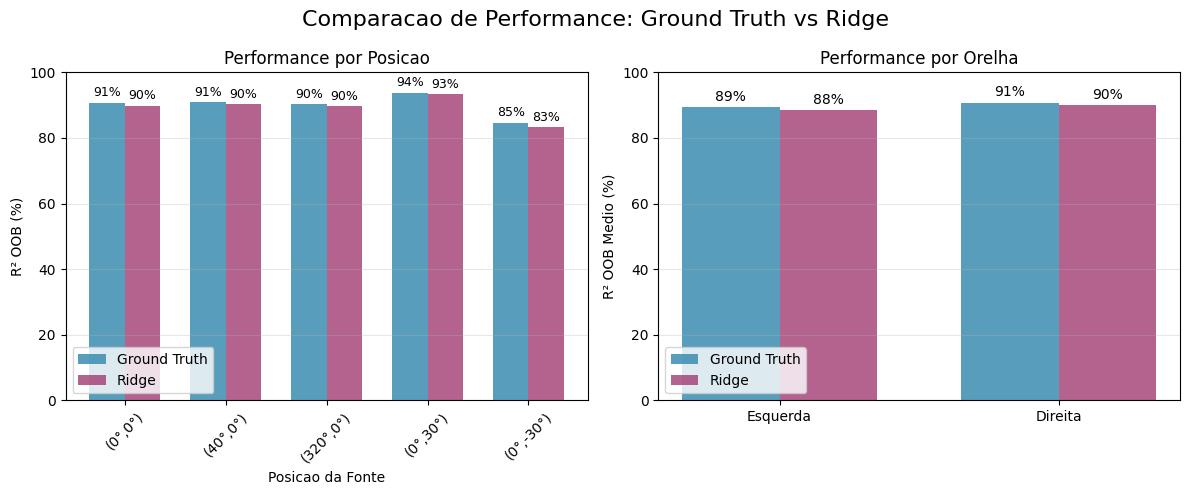

In [16]:
def create_performance_plots():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    positions = ['(0°,0°)', '(40°,0°)', '(320°,0°)', '(0°,30°)', '(0°,-30°)']
    x = np.arange(len(positions))
    width = 0.35
    
    # R^2 por posicao
    ax = axes[0]
    gt_r2_avg = [(gt_results['R2'][0][i] + gt_results['R2'][1][i])/2 * 100 for i in range(5)]
    ridge_r2_avg = [(ridge_results['R2'][0][i] + ridge_results['R2'][1][i])/2 * 100 for i in range(5)]
    
    bars1 = ax.bar(x - width/2, gt_r2_avg, width, label='Ground Truth', color='#2E86AB', alpha=0.8)
    bars2 = ax.bar(x + width/2, ridge_r2_avg, width, label='Ridge', color='#A23B72', alpha=0.8)
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.0f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Posicao da Fonte')
    ax.set_ylabel('R² OOB (%)')
    ax.set_title('Performance por Posicao')
    ax.set_xticks(x)
    ax.set_xticklabels(positions, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100])
    
    # R² por orelha
    ax = axes[1]
    ears = ['Esquerda', 'Direita']
    gt_ears = [np.mean(gt_results['R2'][0])*100, np.mean(gt_results['R2'][1])*100]
    ridge_ears = [np.mean(ridge_results['R2'][0])*100, np.mean(ridge_results['R2'][1])*100]
    
    x_ears = np.arange(len(ears))
    bars1 = ax.bar(x_ears - width/2, gt_ears, width, label='Ground Truth', color='#2E86AB', alpha=0.8)
    bars2 = ax.bar(x_ears + width/2, ridge_ears, width, label='Ridge', color='#A23B72', alpha=0.8)
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.0f}%', ha='center', va='bottom')
    
    ax.set_ylabel('R² OOB Medio (%)')
    ax.set_title('Performance por Orelha')
    ax.set_xticks(x_ears)
    ax.set_xticklabels(ears)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100])
    
    plt.suptitle('Comparacao de Performance: Ground Truth vs Ridge', fontsize=16)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'performance_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# criar visualizacoes
create_performance_plots()

## 9. Salvar Modelos e Resultados

In [15]:
# salvar modelos treinados
print("Salvando modelos...")

# salvar modelos ground truth
for key, model in gt_results['models'].items():
    ear, pos = key
    filename = MODEL_DIR / f"gt_ear{ear}_pos{pos}.pkl"
    joblib.dump(model, filename)

# salvar modelos Ridge
for key, model in ridge_results['models'].items():
    ear, pos = key
    filename = MODEL_DIR / f"ridge_ear{ear}_pos{pos}.pkl"
    joblib.dump(model, filename)

print(f"{len(gt_results['models']) + len(ridge_results['models'])} modelos salvos")

# salvar resumo
summary = {
    'subjects_processados': len(ridge_df),
    'subjects_com_hrtf': len(ridge_hrtf),
    'features_por_modelo': len(feature_cols) + 1,
    'erro_medio_medidas': overall_mean_error,
    'gt_r2_oob': gt_results['summary']['r2_oob_mean'],
    'ridge_r2_oob': ridge_results['summary']['r2_oob_mean'],
    'diferenca_r2': gt_results['summary']['r2_oob_mean'] - ridge_results['summary']['r2_oob_mean']
}

# salvar dados processados
ridge_df.to_csv(OUTPUT_DIR / 'ridge_measurements.csv', index=False)

print("\nResumo Final:")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

print(f"\nResultados salvos em: {OUTPUT_DIR}")

Salvando modelos...
20 modelos salvos

Resumo Final:
subjects_processados: 58
subjects_com_hrtf: 57
features_por_modelo: 24
erro_medio_medidas: 18.88
gt_r2_oob: 0.90
ridge_r2_oob: 0.89
diferenca_r2: 0.01

Resultados salvos em: /home/augusto/projects/PSO-Spatial-Acoustic-Learning/ridge_hrtf_output_v2.1
